#START THE TASK GIVEN BY IT SIMPLERA INSTITUTE

#IMPORT THE IMPORTANT LIBRARY FOR EXPLORATORY DATA ANALYSIS (EDA)

In [4]:
import numpy as np
import pandas as pd
import openpyxl as op
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px




#LOAD THE DATA 

In [5]:
df=pd.read_excel('online_retail_II.xlsx')

#DISPLAY THE FIRTS FEW ROW TO USE (head) METHOD

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


#BASIC INFORMATION 


1 shape of data(row , columns)

In [7]:
df.shape

(525461, 8)

2 colum names and data types

In [8]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [9]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

statistical summary of numerical columns in data

In [10]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,525461.000000,525461,525461.000000,417534.000000
mean,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478
min,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000
25%,1.000000,2010-03-21 12:20:00,1.250000,13983.000000
50%,3.000000,2010-07-06 09:51:00,2.100000,15311.000000
75%,10.000000,2010-10-15 12:45:00,4.210000,16799.000000
max,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000
std,107.424110,NaN,146.126914,1680.811316


#FIND MISSING VALUE AND DUPLICATE 

In [11]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

CHECK THE DUPLICATE VALUE IN DATASET

In [12]:
df.duplicated().sum()

np.int64(6865)

Create the Revenue column

In [13]:
df["Revenue"]=df["Quantity"]*df["Price"]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


Top 10 best-selling products by quantity

In [14]:
top_quantity=df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_quantity

Description
WHITE HANGING HEART T-LIGHT HOLDER    57733
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54698
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46106
ASSORTED COLOUR BIRD ORNAMENT         44925
60 TEATIME FAIRY CAKE CASES           36326
PACK OF 60 PINK PAISLEY CAKE CASES    31822
JUMBO BAG RED RETROSPOT               30727
SMALL POPCORN HOLDER                  29500
STRAWBERRY CERAMIC TRINKET BOX        26563
Name: Quantity, dtype: int64

Visualize the top ten products selling by quantity

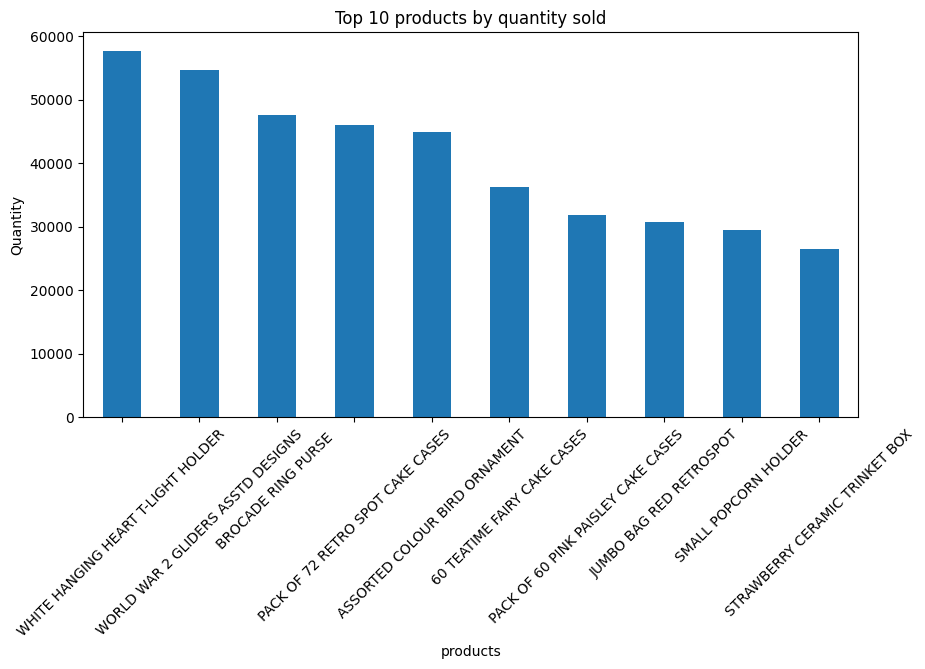

In [15]:
plt.figure(figsize=(10,5))
top_quantity.plot(kind='bar')
plt.title("Top 10 products by quantity sold")
plt.xlabel("products")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.show()

Top 10n product by revenue 

In [16]:
top_revenue=df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_revenue

Description
REGENCY CAKESTAND 3 TIER               163051.46
WHITE HANGING HEART T-LIGHT HOLDER     157865.43
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72454.12
PAPER CHAIN KIT 50'S CHRISTMAS          57870.20
JUMBO BAG RED RETROSPOT                 56444.61
PARTY BUNTING                           49645.52
ROTATING SILVER ANGELS T-LIGHT HLDR     47672.49
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36699.61
Name: Revenue, dtype: float64

Visualize the top 10 revenue

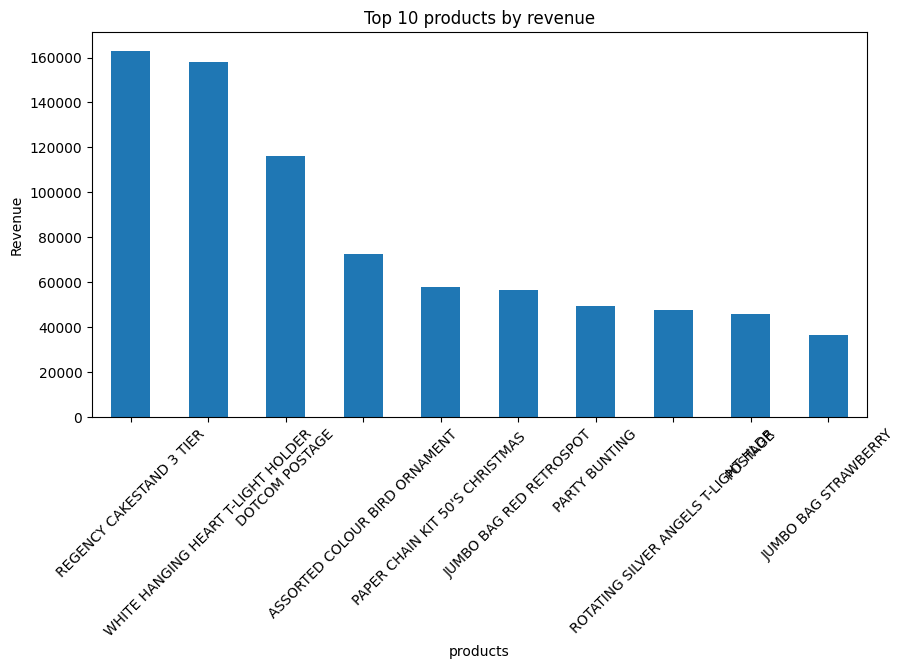

In [17]:
plt.figure(figsize=(10,5))
top_revenue.plot(kind='bar')
plt.title("Top 10 products by revenue")
plt.xlabel("products")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Analyze the sales by country

In [18]:
country_sales=df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
country_sales

Country
United Kingdom    8194777.533
EIRE               352242.730
Netherlands        263863.410
Germany            196290.351
France             130769.900
Sweden              51213.510
Denmark             46972.950
Switzerland         43343.410
Spain               37084.900
Australia           30051.800
Name: Revenue, dtype: float64

Visualize the top ten country sales

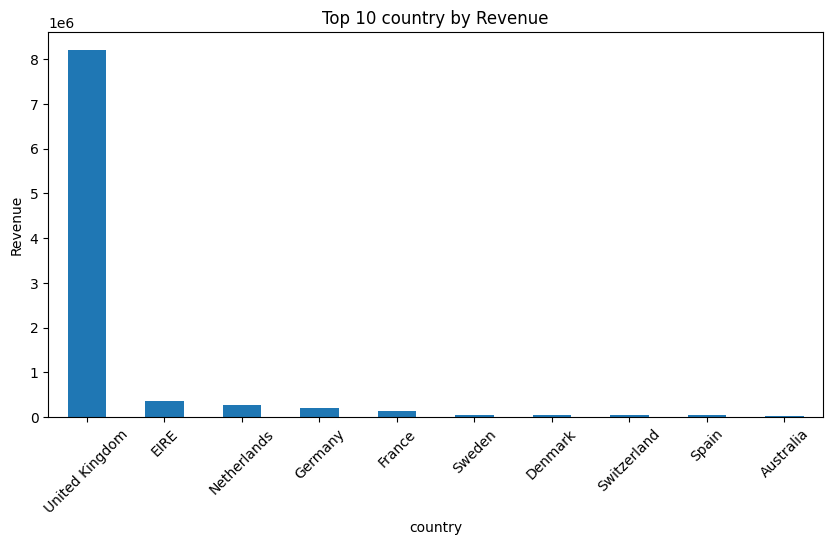

In [19]:
plt.figure(figsize=(10,5))
country_sales.plot(kind='bar')
plt.title("Top 10 country by Revenue")
plt.xlabel("country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Monthly Revenue Trend

In [20]:
#convert the invoice date to datetime
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [21]:
#extract month
df["Month"]=df["InvoiceDate"].dt.to_period("M")


find the montly revenue

In [22]:
monthly_revenue=df.groupby("Month")["Revenue"].sum()
monthly_revenue

Month
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12     377488.450
Freq: M, Name: Revenue, dtype: float64

visualize the montly revenue trend

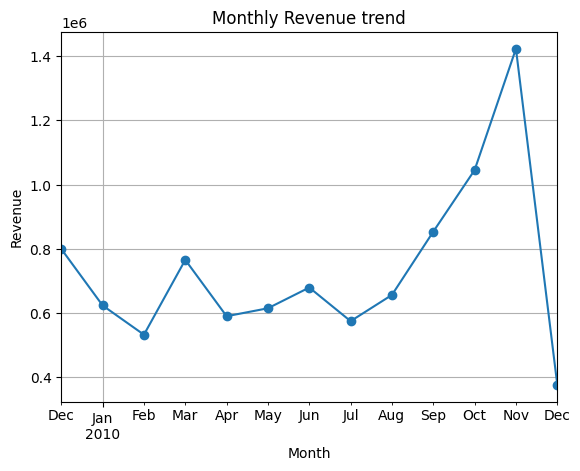

In [23]:
plt.Figure(figsize=(12,5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

correlation heat map

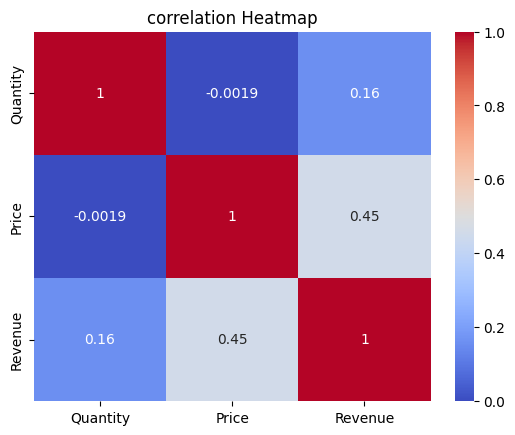

In [24]:
plt.Figure(figsize=(8,6))
sns.heatmap(df[["Quantity", "Price", "Revenue"]].corr(),annot=True, cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

boxplot without filter

Text(0.5, 1.0, 'Boxplot of quantity')

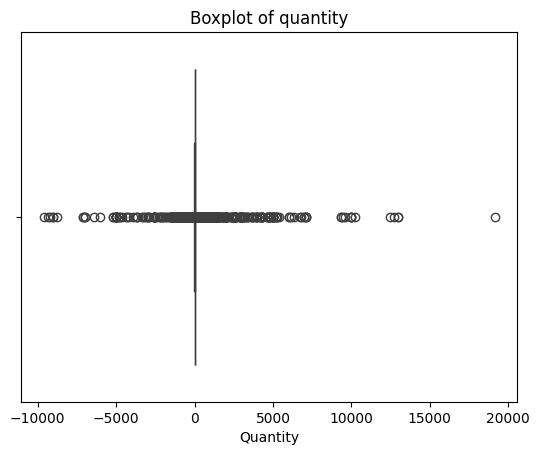

In [30]:
sns.boxplot(x=df["Quantity"])
plt.title("Boxplot of quantity")


box plot for outlier with filtered data

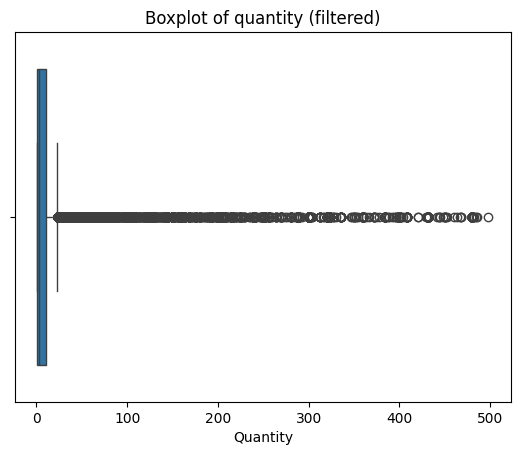

In [31]:

filtere_df=df[(df['Quantity']>0) & (df['Quantity']<500)]
sns.boxplot(x=filtere_df["Quantity"])
plt.title("Boxplot of quantity (filtered)")
plt.show()

boxplot for price

Text(0.5, 1.0, 'Boxplot of Price')

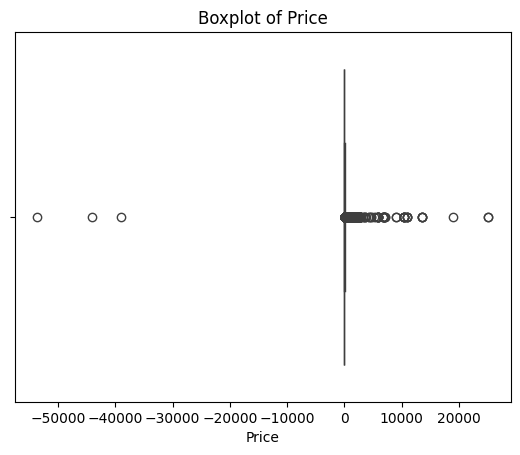

In [33]:
sns.boxplot(x=df['Price'])
plt.title("Boxplot of Price")


boxplot for revenue

Text(0.5, 1.0, 'Boxplot for reveneue')

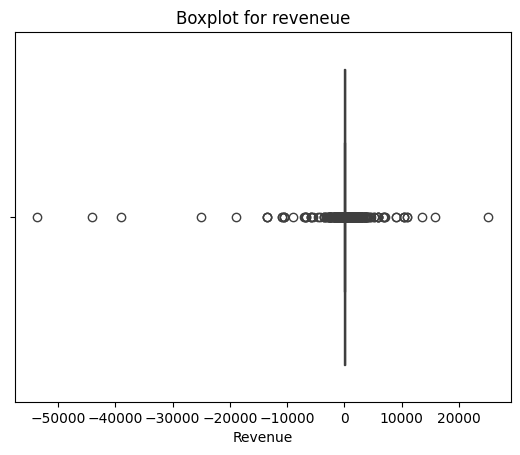

In [34]:
sns.boxplot(x=df['Revenue'])
plt.title("Boxplot for reveneue")